In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Peep into a file

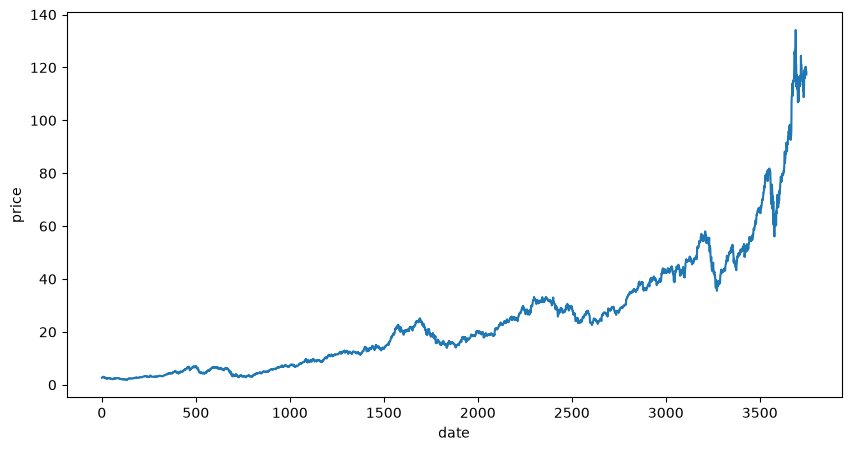

In [2]:
#df = pd.read_csv(os.path.join("./stockprice", "AAPL.csv"))
df = pd.read_csv("https://raw.githubusercontent.com/hyerica-bdml/class-2026-nlp/refs/heads/main/data/AAPL.csv")

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.xlabel("date")
plt.ylabel("price")
plt.show()

### Setting for preprocessing

In [3]:
split_fraction = 0.75
train_split = int(split_fraction * int(df.shape[0]))

sequence_length = 60
future = 5
learning_rate = 0.001
epochs = 50

features = df[['High', 'Low', 'Open', 'Close', 'Volume']]

In [40]:
# early 0.75 days of records will be used for training
train_data = features.iloc[0 : train_split]
val_data = features.iloc[train_split:]
n_train = len(train_data) - sequence_length - future
n_val = len(val_data) - sequence_length - future

In [47]:
x_train = train_data.values[:-future]
y_train = train_data.values[sequence_length+future:, [0]]
print(x_train.shape, y_train.shape)

(2806, 5) (2746, 1)


In [48]:
x_test = val_data.values[:-future]
y_test = val_data.values[sequence_length+future:, [0]]
print(x_test.shape, y_test.shape)

(933, 5) (873, 1)


In [51]:
def timeseries_dataset_from_array(x, y, sequence_length):
    """Create sequences from time series data"""
    sequences = []
    targets = []
    for i in range(len(y)):
        sequences.append(x[i:i + sequence_length])
        targets.append(y[i])
    return np.array(sequences), np.array(targets) if y is not None else None

x_train_seq, y_train_seq = timeseries_dataset_from_array(x_train, y_train, sequence_length)
x_test_seq, y_test_seq = timeseries_dataset_from_array(x_test, y_test, sequence_length)

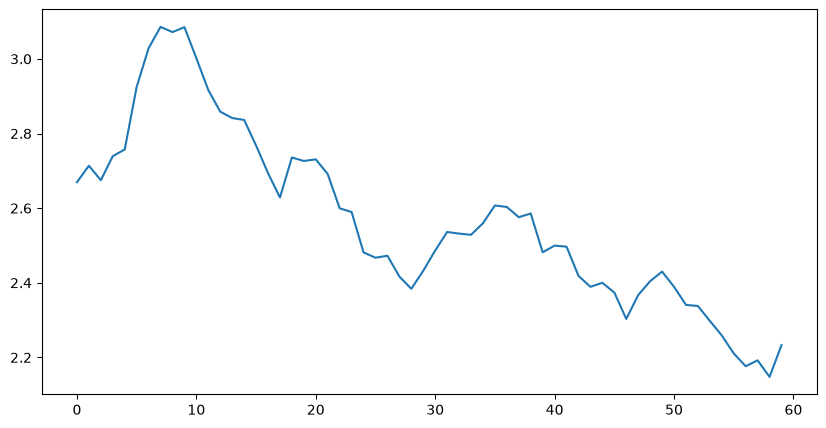

In [14]:
plt.figure(figsize=(10,5))
plt.plot(x_train_seq[0, :, 0])
plt.show()

In [53]:
def normalize_sequence(x_batch, y_batch):
    """Normalize sequences using mean and std computed per sequence"""
    # x_batch: (batch, seq_len, features)
    data_mean = np.mean(x_batch, axis=1, keepdims=True)  # (batch, 1, features)
    data_std = np.std(x_batch, axis=1, keepdims=True)    # (batch, 1, features)
    data_std = np.where(data_std == 0, 1, data_std)  # Avoid division by zero
    
    x_normalized = (x_batch - data_mean) / data_std
    y_normalized = (y_batch - data_mean[:, 0, 0:1]) / data_std[:, 0, 0:1]
    
    return x_normalized, y_normalized

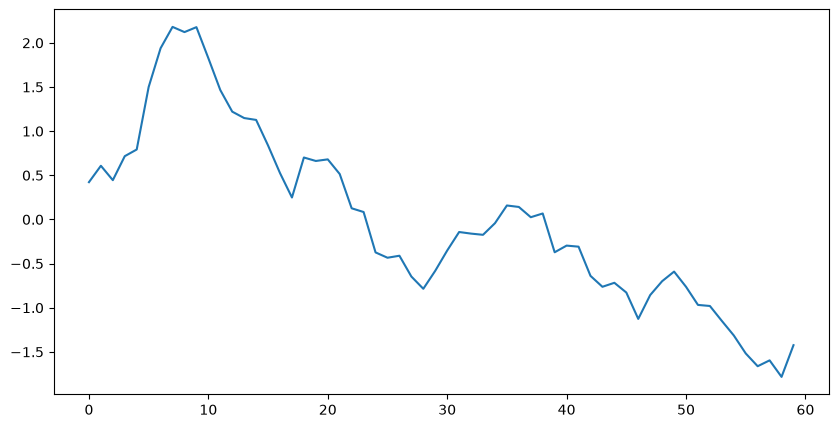

In [54]:
x_norm, y_norm = normalize_sequence(x_train_seq, y_train_seq)
plt.figure(figsize=(10,5))
plt.plot(x_norm[0, :, 0])
plt.show()

### In summary...

In [59]:
items = ['AAPL', 'IBM', 'INTC', 'AMD', 'MSFT']
#item_dfs = [ pd.read_csv(os.path.join("./stockprice", f"{i}.csv")) for i in items ]
item_dfs = [ pd.read_csv(f"https://raw.githubusercontent.com/hyerica-bdml/class-2026-nlp/refs/heads/main/data/{i}.csv") for i in items ]

split_fraction = 0.75
train_split = int(split_fraction * int(item_dfs[0].shape[0]))

sequence_length = 60
future = 5

In [62]:
def preprocessing_datasets(df):
    features = df[['High', 'Low', 'Open', 'Close', 'Volume']]
    
    train_data = features.loc[0 : train_split - 1]
    val_data = features.loc[train_split:]
    
    train_data = features.iloc[0 : train_split]
    val_data = features.iloc[train_split:]

    x_train = train_data.values[:-future]
    y_train = train_data.values[sequence_length+future:, [0]]

    x_test = val_data.values[:-future]
    y_test = val_data.values[sequence_length+future:, [0]]
    
    # Create sequences
    x_train_seq, y_train_seq = timeseries_dataset_from_array(x_train, y_train, sequence_length)
    x_test_seq, y_test_seq = timeseries_dataset_from_array(x_test, y_test, sequence_length)
    
    # Normalize
    x_train_norm, y_train_norm = normalize_sequence(x_train_seq, y_train_seq)
    x_test_norm, y_test_norm = normalize_sequence(x_test_seq, y_test_seq)
    
    return x_train_norm, y_train_norm, x_test_norm, y_test_norm

In [63]:
results = [preprocessing_datasets(df) for df in item_dfs]

In [64]:
x_train_list, y_train_list = [], []
for x_tr, y_tr, _, _ in results:
    x_train_list.append(x_tr)
    y_train_list.append(y_tr)
    
x_train = np.concatenate(x_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

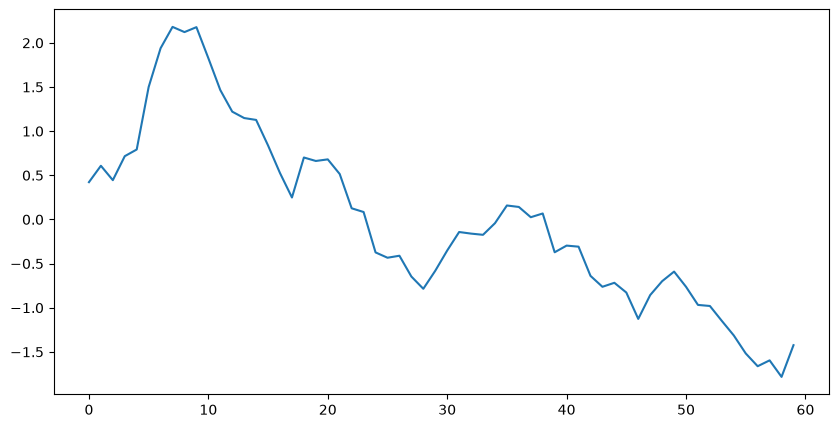

In [92]:
plt.figure(figsize=(10,5))
plt.plot(x_train[0, :, 0])
plt.show()

In [93]:
x_test_list, y_test_list = [], []
for _, _, x_te, y_te in results:
    x_test_list.append(x_te)
    y_test_list.append(y_te)
    
x_test = np.concatenate(x_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

### Save arrays

In [110]:
np.savez('stockprice5_pytorch', x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)

### Defining recurrent layers

In [69]:
input_dim = 5
n_rnn_layers = 6
x_dims = 64
latent_dims = 64

In [ ]:
class SimpleRNNLayer(nn.Module):
    # --- fill here ---

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, x_dims, latent_dims, n_rnn_layers):
        # --- fill here ---
        
    def forward(self, x, h_prevs):
        # --- fill here ---

In [72]:
encoder = Encoder(input_dim, x_dims, latent_dims, n_rnn_layers).to(device)
print(encoder)

Encoder(
  (input_fc): Linear(in_features=5, out_features=64, bias=True)
  (rnn_layers): ModuleList(
    (0-5): 6 x SimpleRNNLayer(
      (fc_h): Linear(in_features=128, out_features=64, bias=True)
      (fc_x): Linear(in_features=64, out_features=64, bias=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
)


In [73]:
# Print model summary
total_params = sum(p.numel() for p in encoder.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 74880


In [74]:
# Output shape info
print(f"Output: {n_rnn_layers} tensors of shape (batch, {latent_dims})")

Output: 6 tensors of shape (batch, 64)


In [75]:
# Test if encoder works
tmp_x_batch = torch.randn(32, input_dim).to(device)
tmp_h = [torch.zeros(32, latent_dims).to(device) for _ in range(n_rnn_layers)]
output = encoder(tmp_x_batch, tmp_h)
print("Encoder output shapes:", [h.shape for h in output])

Encoder output shapes: [torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([32, 64])]


In [ ]:
class Regressor(nn.Module):
    # --- fill here ---

In [77]:
regressor = Regressor(latent_dims, n_rnn_layers).to(device)
print(regressor)

Regressor(
  (fc): Linear(in_features=384, out_features=1, bias=True)
)


In [78]:
# Test if regressor works
tmp_h = torch.randn(32, latent_dims * n_rnn_layers).to(device)
output = regressor(tmp_h)
print("Regressor output shape:", output.shape)

Regressor output shape: torch.Size([32, 1])


In [ ]:
def forward_rnn(x_batch, encoder, regressor, training=True):
    # --- fill here ---

In [84]:
# Test if forward_rnn works
test_x_batch = torch.randn(32, sequence_length, input_dim).to(device)
output = forward_rnn(test_x_batch, encoder, regressor)
print("Forward RNN output shape:", output.shape)

Forward RNN output shape: torch.Size([32, 1])


### Loss function

In [81]:
criterion = nn.L1Loss()  # Mean Absolute Error (MAE)

### Training

In [82]:
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(regressor.parameters()), 
    lr=1e-5
)

In [99]:
batch_size = 128
epochs = 50

# Convert numpy arrays to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)


In [100]:
x_train_tensor.shape, y_train_tensor.shape, x_test_tensor.shape, y_test_tensor.shape

(torch.Size([13730, 60, 5]),
 torch.Size([13730, 1]),
 torch.Size([4365, 60, 5]),
 torch.Size([4365, 1]))

In [101]:

# Create DataLoader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    start = time.time()
    encoder.train()
    regressor.train()
    
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        y_pred = forward_rnn(x_batch, encoder, regressor, training=True)
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        optimizer.step()
    
    # Evaluate on test set
    encoder.eval()
    regressor.eval()
    with torch.no_grad():
        y_test_pred = forward_rnn(x_test_tensor, encoder, regressor, training=False)
        test_loss = criterion(y_test_pred, y_test_tensor)
    
    print(f'Time for epoch {epoch + 1} is {time.time() - start:.2f} sec: loss = {test_loss.item():.6f}')

Time for epoch 1 is 23.66 sec: loss = 1.388630
Time for epoch 2 is 23.45 sec: loss = 1.344293
Time for epoch 3 is 23.36 sec: loss = 1.287899
Time for epoch 4 is 23.76 sec: loss = 1.214311
Time for epoch 5 is 23.67 sec: loss = 1.115556
Time for epoch 6 is 23.68 sec: loss = 0.985049
Time for epoch 7 is 23.49 sec: loss = 0.857237
Time for epoch 8 is 23.47 sec: loss = 0.819538
Time for epoch 9 is 23.55 sec: loss = 0.814164
Time for epoch 10 is 23.48 sec: loss = 0.808734
Time for epoch 11 is 23.69 sec: loss = 0.804492
Time for epoch 12 is 23.77 sec: loss = 0.801171
Time for epoch 13 is 23.78 sec: loss = 0.798955
Time for epoch 14 is 23.62 sec: loss = 0.798590
Time for epoch 15 is 23.40 sec: loss = 0.794220
Time for epoch 16 is 23.35 sec: loss = 0.792933
Time for epoch 17 is 23.33 sec: loss = 0.789755
Time for epoch 18 is 23.45 sec: loss = 0.789847
Time for epoch 19 is 24.01 sec: loss = 0.786948
Time for epoch 20 is 23.59 sec: loss = 0.785841
Time for epoch 21 is 23.52 sec: loss = 0.785547
T

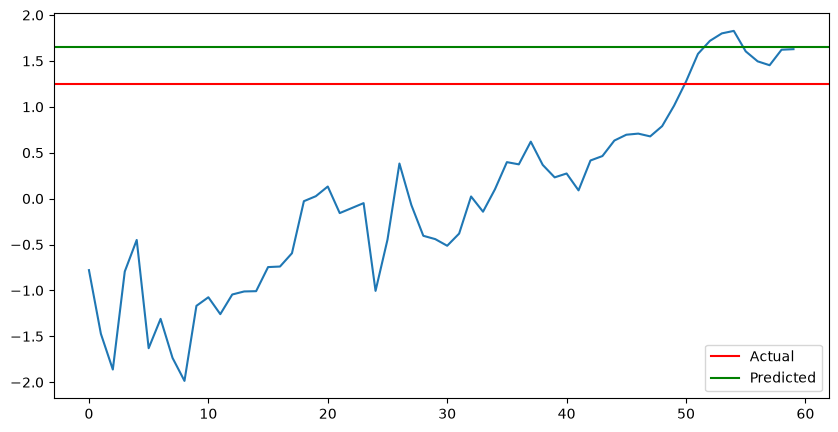

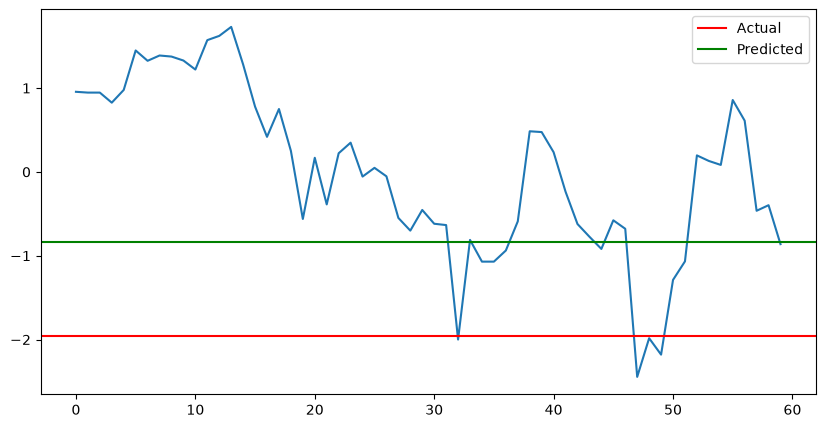

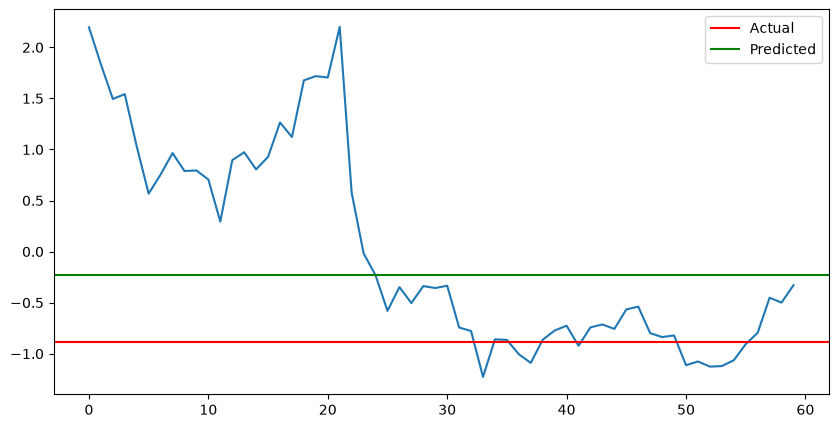

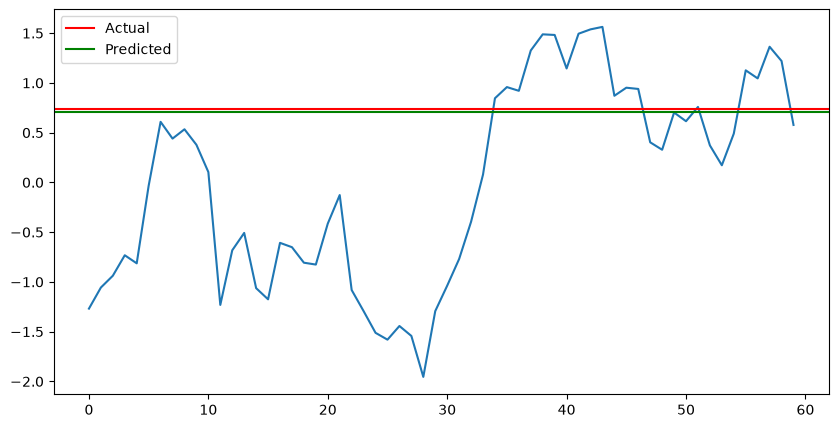

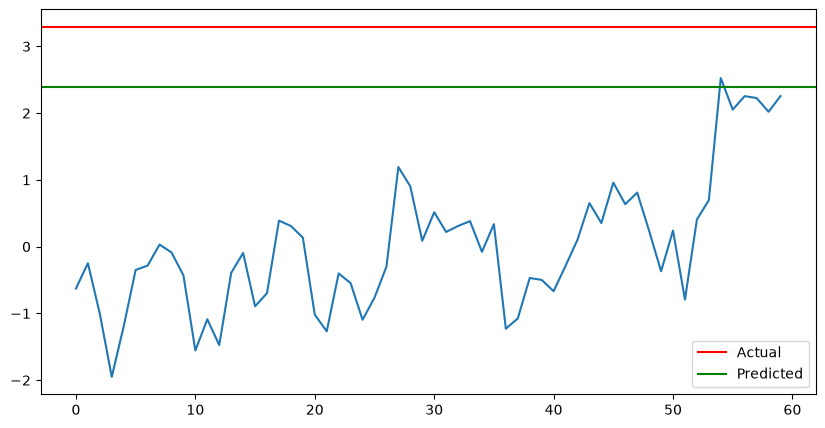

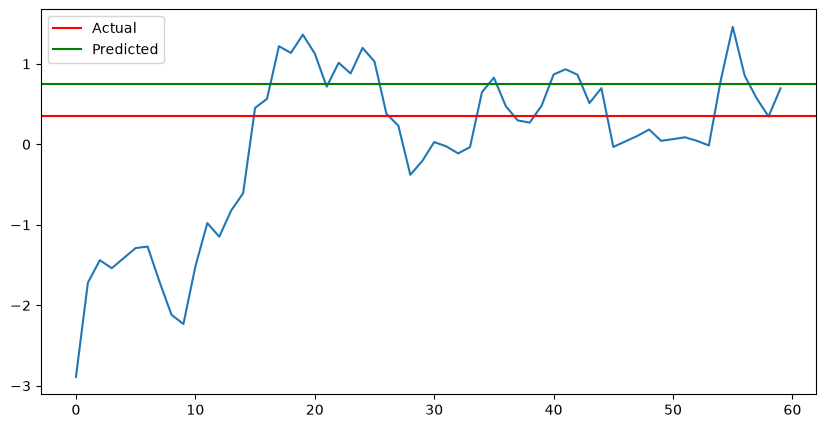

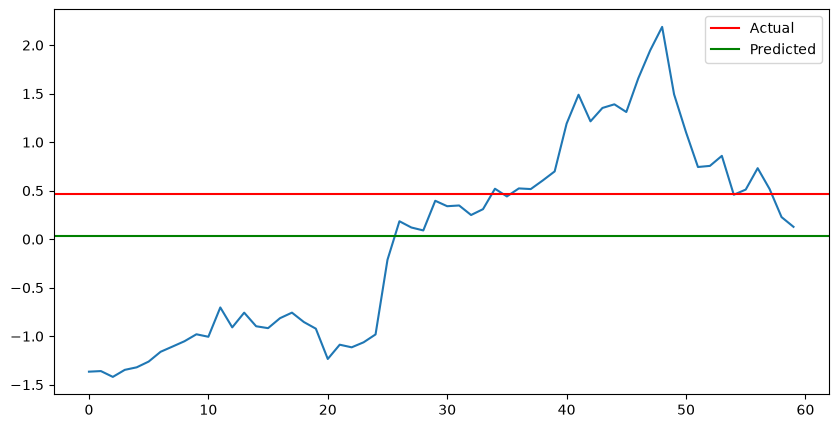

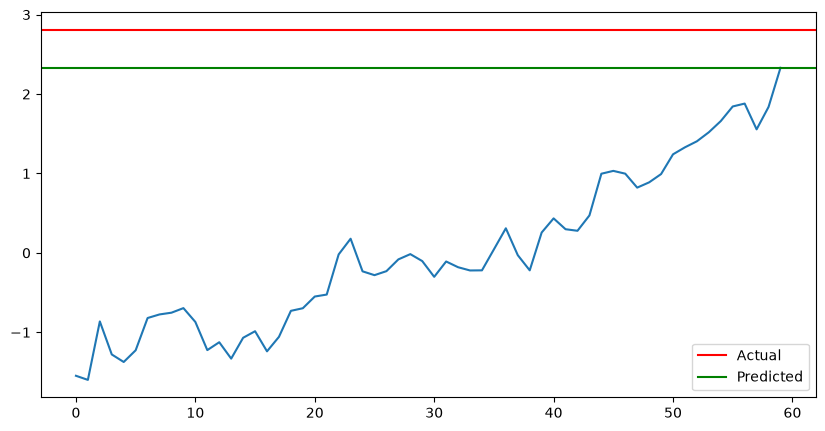

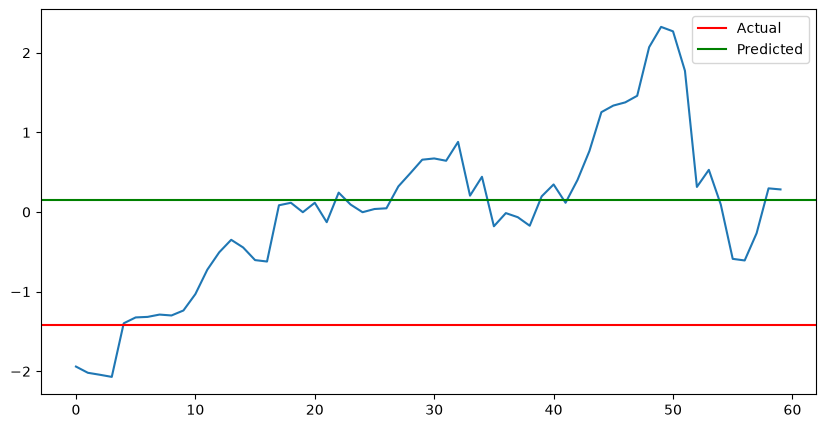

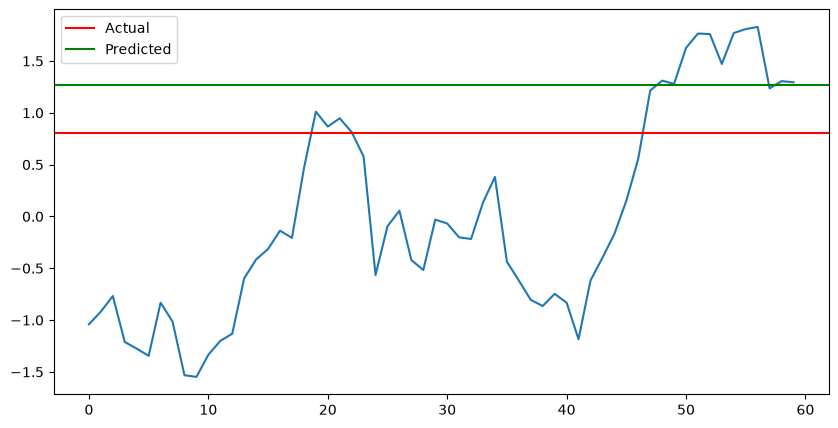

In [109]:
encoder.eval()
regressor.eval()

for _ in range(10):
    idx = np.random.randint(x_test.shape[0])
    x_sample = torch.tensor(x_test[idx:idx+1], dtype=torch.float32).to(device)
    
    with torch.no_grad():
        y_pred = forward_rnn(x_sample, encoder, regressor, training=False)
    
    plt.figure(figsize=(10, 5))
    plt.plot(x_test[idx, :, 0])
    plt.axhline(y_test[idx, 0], color='r', label='Actual')
    plt.axhline(y_pred.cpu().numpy()[0, 0], color='g', label='Predicted')
    plt.legend()
    plt.show()